In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

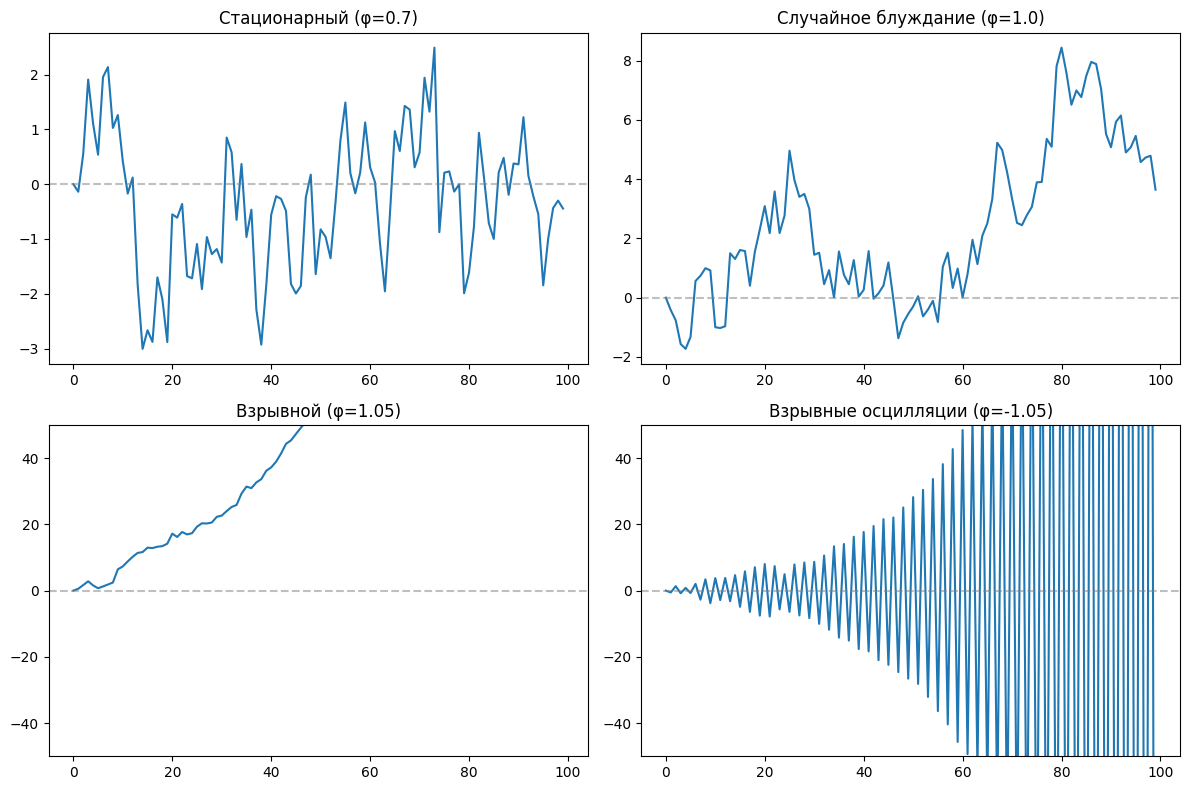

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ar1(phi, n=100):
    """Симуляция AR(1) процесса"""
    y = np.zeros(n)
    errors = np.random.normal(0, 1, n)
    for t in range(1, n):
        y[t] = phi * y[t-1] + errors[t]
    return y

np.random.seed(42)
phis = [0.7, 1.0, 1.05, -1.05]
titles = ['Стационарный (φ=0.7)', 'Случайное блуждание (φ=1.0)', 
          'Взрывной (φ=1.05)', 'Взрывные осцилляции (φ=-1.05)']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, phi, title in zip(axes.ravel(), phis, titles):
    y = simulate_ar1(phi, n=100)
    ax.plot(y)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(title)
    ax.set_ylim(-50, 50) if abs(phi) > 1 else None

plt.tight_layout()
plt.show()

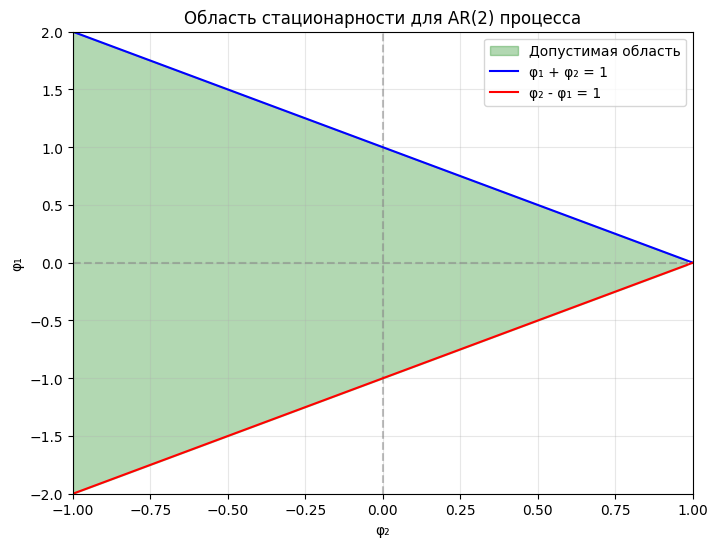

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Рисуем область допустимых значений для AR(2)
phi2 = np.linspace(-1, 1, 100)
phi1_upper = 1 - phi2
phi1_lower = phi2 - 1

plt.figure(figsize=(8, 6))
plt.fill_between(phi2, phi1_lower, phi1_upper, where=(phi1_upper > phi1_lower), 
                 alpha=0.3, color='green', label='Допустимая область')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.plot(phi2, phi1_upper, 'b-', label='φ₁ + φ₂ = 1')
plt.plot(phi2, phi1_lower, 'r-', label='φ₂ - φ₁ = 1')
plt.xlim(-1, 1)
plt.ylim(-2, 2)
plt.xlabel('φ₂')
plt.ylabel('φ₁')
plt.title('Область стационарности для AR(2) процесса')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [4]:
from statsmodels.tsa.arima_process import ArmaProcess


# Демонстрация: обратимый и необратимый MA(1) с одинаковой ACF
from statsmodels.tsa.stattools import acf

# Обратимый MA(1): θ = 0.5
ma_invertible = ArmaProcess(ar=[1], ma=[1, 0.5])
# Необратимый MA(1): θ = 2 (дает ту же ACF, что и θ = 0.5)
ma_non_invertible = ArmaProcess(ar=[1], ma=[1, 2])

print("ACF для обратимого MA(1) с θ=0.5:")
print(ma_invertible.acf(lags=5)[:5])

print("\nACF для необратимого MA(1) с θ=2:")
print(ma_non_invertible.acf(lags=5)[:5])

# Одинаковые! Но прогнозы будут разными

ACF для обратимого MA(1) с θ=0.5:
[1.  0.4 0.  0.  0. ]

ACF для необратимого MA(1) с θ=2:
[1.  0.4 0.  0.  0. ]


In [5]:
def check_arma_stability(ar_coefs, ma_coefs):
    """
    Проверяет стационарность AR и обратимость MA
    
    ar_coefs: список [φ₁, φ₂, ..., φₚ]
    ma_coefs: список [θ₁, θ₂, ..., θ_q]
    """
    # Для statsmodels формат: [1, -φ₁, -φ₂, ...]
    ar_param = [1] + [-c for c in ar_coefs]
    ma_param = [1] + ma_coefs
    
    process = ArmaProcess(ar=ar_param, ma=ma_param)
    
    print(f"AR коэффициенты: {ar_coefs}")
    print(f"MA коэффициенты: {ma_coefs}")
    print(f"AR стационарен: {process.isstationary}")
    print(f"MA обратим: {process.isinvertible}")
    
    if not process.isstationary:
        print("AR корни:", process.ar_roots)
        print("Модули AR корней:", [abs(r) for r in process.ar_roots])
    
    if not process.isinvertible:
        print("MA корни:", process.ma_roots)
        print("Модули MA корней:", [abs(r) for r in process.ma_roots])
    
    return process.isstationary, process.isinvertible

# Проверяем разные комбинации
print("="*50)
check_arma_stability([0.7], [0.5])  # Хорошая модель

print("\n" + "="*50)
check_arma_stability([1.2], [0.5])  # Плохая AR (нестационарная)

print("\n" + "="*50)
check_arma_stability([0.7], [1.2])  # Плохая MA (необратимая)

AR коэффициенты: [0.7]
MA коэффициенты: [0.5]
AR стационарен: True
MA обратим: True

AR коэффициенты: [1.2]
MA коэффициенты: [0.5]
AR стационарен: False
MA обратим: True


AttributeError: 'ArmaProcess' object has no attribute 'ar_roots'